In [ ]:
## model training and evaluation
## builds and trains a CNN for gravitational wave detection

In [11]:
import numpy as np
import matplotlib.pyplot as plt
import os
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

print(f"TensorFlow: {tf.__version__}")

BASE_DIR    = r'C:\Users\srika\gw_wd'
DATASET_DIR = os.path.join(BASE_DIR, 'data', 'dataset_qtransform')
MODELS_DIR  = os.path.join(BASE_DIR, 'models')
RESULTS_DIR = os.path.join(BASE_DIR, 'results')

print("\n")
print("LOADING Q-TRANSFORM DATASET")


X_train = np.load(os.path.join(DATASET_DIR, 'X_train.npy'))
X_test  = np.load(os.path.join(DATASET_DIR, 'X_test.npy'))
y_train = np.load(os.path.join(DATASET_DIR, 'y_train.npy'))
y_test  = np.load(os.path.join(DATASET_DIR, 'y_test.npy'))

print(f"\n Data loaded:")
print(f"   X_train: {X_train.shape}")
print(f"   y_train: {y_train.shape} (signal={np.sum(y_train==1)}, noise={np.sum(y_train==0)})")
print(f"   X_test : {X_test.shape}")
print(f"   y_test : {y_test.shape} (signal={np.sum(y_test==1)}, noise={np.sum(y_test==0)})")

TensorFlow: 2.20.0


LOADING Q-TRANSFORM DATASET

 Data loaded:
   X_train: (38, 224, 224, 3)
   y_train: (38,) (signal=18, noise=20)
   X_test : (10, 224, 224, 3)
   y_test : (10,) (signal=6, noise=4)


In [12]:

print("BUILDING CNN MODEL (Q-TRANSFORM OPTIMIZED)\n")


model = models.Sequential([
    # Input
    layers.Input(shape=(224, 224, 3)),
    
    # Block 1
    layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),
    
    # Block 2
    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),
    
    # Block 3
    layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.3),
    
    # Block 4
    layers.Conv2D(256, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.3),
    
    # Dense
    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.5),
    
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    
    # Output
    layers.Dense(1, activation='sigmoid')
])

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy',
             keras.metrics.Precision(name='precision'),
             keras.metrics.Recall(name='recall')]
)

print("\n Model built!")
model.summary()

BUILDING CNN MODEL (Q-TRANSFORM OPTIMIZED)


 Model built!


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_14 (Conv2D)                   │ (None, 224, 224, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_16               │ (None, 224, 224, 32)        │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_15 (Conv2D)                   │ (None, 224, 224, 32)        │           9,248 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_17               │ (None, 224, 224, 32)        │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_8 (MaxPooling2D)       │ (None, 112, 112, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_12 (Dropout)                 │ (None, 112, 112, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_16 (Conv2D)                   │ (None, 112, 112, 64)        │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_18               │ (None, 112, 112, 64)        │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_17 (Conv2D)                   │ (None, 112, 112, 64)        │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_19               │ (None, 112, 112, 64)        │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_9 (MaxPooling2D)       │ (None, 56, 56, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_13 (Dropout)                 │ (None, 56, 56, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_18 (Conv2D)                   │ (None, 56, 56, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_20               │ (None, 56, 56, 128)         │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_19 (Conv2D)                   │ (None, 56, 56, 128)         │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_21               │ (None, 56, 56, 128)         │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_10 (MaxPooling2D)      │ (None, 28, 28, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_14 (Dropout)                 │ (None, 28, 28, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼──────────────

 Total params: 13,464,353 (51.36 MB)

 Trainable params: 13,462,433 (51.36 MB)

 Non-trainable params: 1,920 (7.50 KB)

In [13]:

print("TRAINING MODEL\n")


# Callbacks
checkpoint = ModelCheckpoint(
    os.path.join(MODELS_DIR, 'best_model_qtransform.keras'),
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=7,
    verbose=1
)

# Train
print("\n Training started...")
print("  ~5-10 minutes\n")

history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=50,
    batch_size=8,  # Smaller batch = better for small dataset
    callbacks=[checkpoint, early_stop, reduce_lr],
    verbose=1
)

print("\n Training complete!")

TRAINING MODEL


 Training started...
  ~5-10 minutes

Epoch 1/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8257 - loss: 0.3399 - precision: 0.7973 - recall: 0.8709
Epoch 1: val_accuracy improved from -inf to 0.40000, saving model to C:\Users\srika\gw_wd\models\best_model_qtransform.keras
5/5 ━━━━━━━━━━━━━━━━━━━━ 11s 1s/step - accuracy: 0.8240 - loss: 0.3491 - precision: 0.8089 - recall: 0.8461 - val_accuracy: 0.4000 - val_loss: 1.1485 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 0.0010
Epoch 2/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9175 - loss: 0.2748 - precision: 0.9567 - recall: 0.8777
Epoch 2: val_accuracy did not improve from 0.40000
5/5 ━━━━━━━━━━━━━━━━━━━━ 6s 1s/step - accuracy: 0.9181 - loss: 0.2690 - precision: 0.9541 - recall: 0.8796 - val_accuracy: 0.4000 - val_loss: 1.6440 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 0.0010
Epoch 3/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9427 - loss: 0.1340

In [14]:

print("MODEL EVALUATION\n")


test_loss, test_acc, test_prec, test_rec = model.evaluate(X_test, y_test, verbose=0)

print(f"\n Test Performance:")
print(f"   Accuracy : {test_acc*100:.2f}%")
print(f"   Precision: {test_prec*100:.2f}%")
print(f"   Recall   : {test_rec*100:.2f}%")
print(f"   Loss     : {test_loss:.4f}")

f1 = 2 * (test_prec * test_rec) / (test_prec + test_rec + 1e-10)
print(f"   F1-Score : {f1*100:.2f}%")

# Predictions
y_pred_prob = model.predict(X_test, verbose=0)
y_pred = (y_pred_prob > 0.5).astype(int).flatten()

# Confusion Matrix
from sklearn.metrics import confusion_matrix, classification_report

cm = confusion_matrix(y_test, y_pred)

print("\n Confusion Matrix:")
print(f"                Predicted")
print(f"              Noise  Signal")
print(f"Actual Noise    {cm[0,0]:3d}    {cm[0,1]:3d}")
print(f"      Signal    {cm[1,0]:3d}    {cm[1,1]:3d}")

print("\n Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Noise', 'Signal']))

MODEL EVALUATION


 Test Performance:
   Accuracy : 40.00%
   Precision: 0.00%
   Recall   : 0.00%
   Loss     : 1.1018
   F1-Score : 0.00%

 Confusion Matrix:
                Predicted
              Noise  Signal
Actual Noise      4      0
      Signal      6      0

 Classification Report:
              precision    recall  f1-score   support

       Noise       0.40      1.00      0.57         4
      Signal       0.00      0.00      0.00         6

    accuracy                           0.40        10
   macro avg       0.20      0.50      0.29        10
weighted avg       0.16      0.40      0.23        10



C:\Users\srika\anaconda3\envs\gw\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\srika\anaconda3\envs\gw\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\srika\anaconda3\envs\gw\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


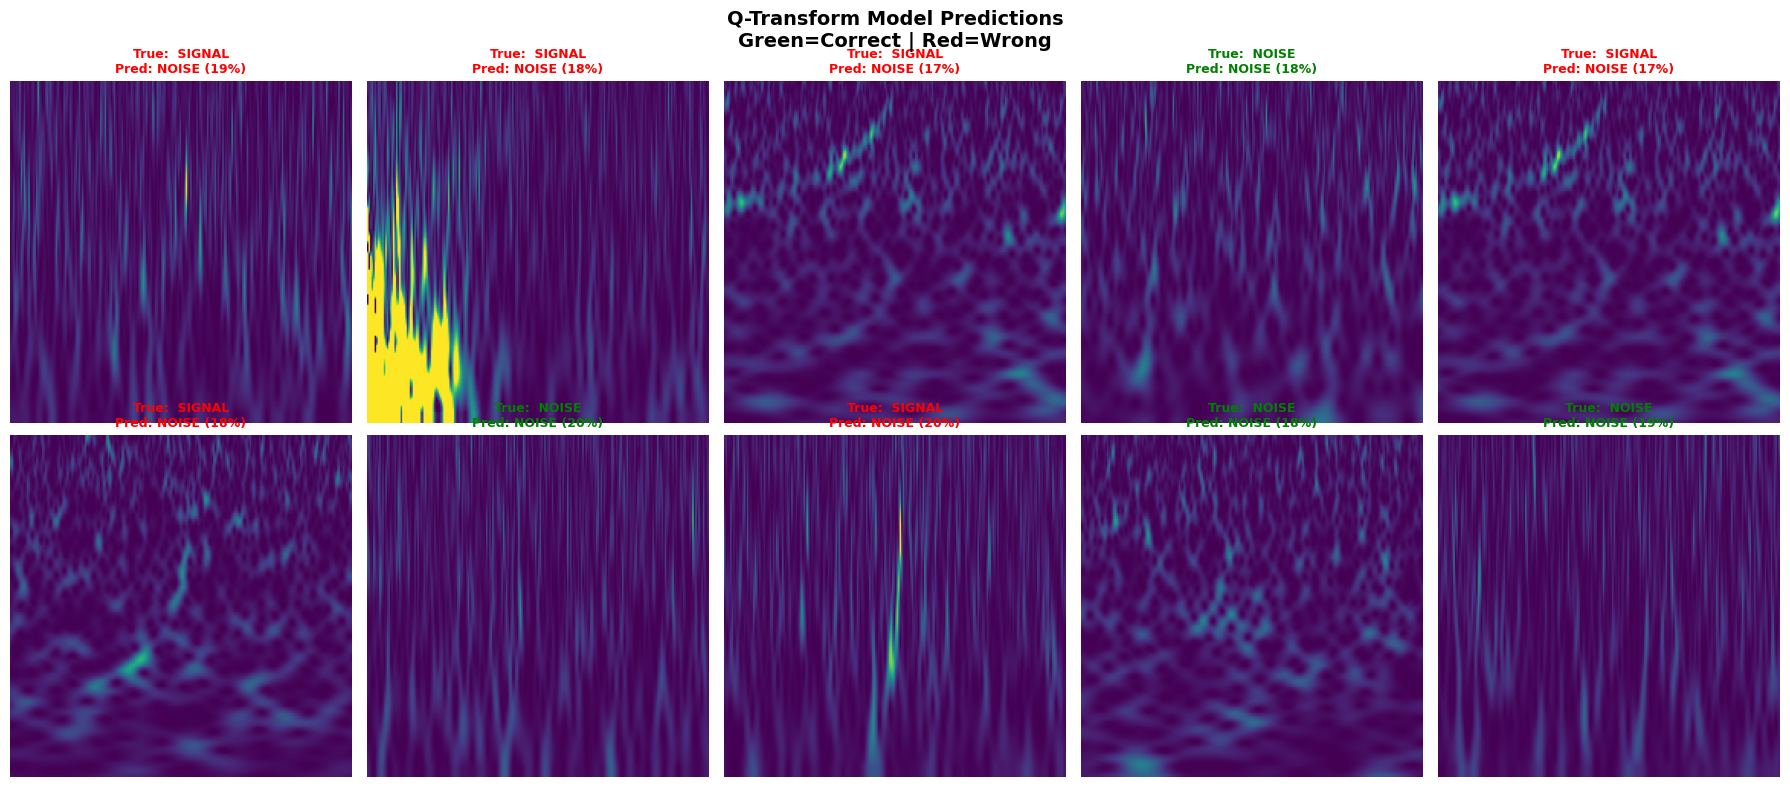


 Correct predictions: 4/10


In [15]:
# Show predictions
fig, axes = plt.subplots(2, 5, figsize=(18, 8))

for i in range(10):
    row, col = i // 5, i % 5
    
    img = X_test[i]
    true = y_test[i]
    prob = y_pred_prob[i][0]
    pred = y_pred[i]
    
    axes[row, col].imshow(img)
    
    true_txt = ' SIGNAL' if true == 1 else ' NOISE'
    pred_txt = 'SIGNAL' if pred == 1 else 'NOISE'
    color = 'green' if true == pred else 'red'
    
    axes[row, col].set_title(
        f'True: {true_txt}\n'
        f'Pred: {pred_txt} ({prob*100:.0f}%)',
        fontsize=9, fontweight='bold', color=color
    )
    axes[row, col].axis('off')

plt.suptitle('Q-Transform Model Predictions\nGreen=Correct | Red=Wrong',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"\n Correct predictions: {np.sum(y_test == y_pred)}/{len(y_test)}")